# Menstrual Cycle Forecasting — Exploratory Data Analysis

---

## 1. Imports and Configuration

In [34]:
# ── Standard scientific stack ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# ── Plotting defaults ──────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

# ── Load dataset ───────────────────────────────────────────────────────────
# Path resolves relative to the current working directory (project root).
# Works correctly whether you open the notebook in Jupyter or run it via
# nbconvert, as long as you launch from the project root folder.
DATA_PATH = Path('Data') / 'menstrual_cycle_dataset.csv'

df = pd.read_csv(DATA_PATH)
print(f'Shape               : {df.shape}')

Shape               : (895, 12)


## 2. Dataset Overview

In [2]:
# ── Basic dimensions ───────────────────────────────────────────────────────
print('Shape (rows × columns):', df.shape)
print('\nColumn names:')
for col in df.columns:
    print(' -', col)

Shape (rows × columns): (895, 12)

Column names:
 - User ID
 - Age
 - BMI
 - Stress Level
 - Exercise Frequency
 - Sleep Hours
 - Diet
 - Cycle Start Date
 - Cycle Length
 - Period Length
 - Next Cycle Start Date
 - Symptoms


In [4]:
df.head()

,User ID,Age,BMI,Stress Level,Exercise Frequency,Sleep Hours,Diet,Cycle Start Date,Cycle Length,Period Length,Next Cycle Start Date,Symptoms
0,1,18,29.28,2,Moderate,5.4,Low Carb,2024-11-13 20:52:34.915012,26,7,2024-12-09 20:52:34.915012,Headache
1,1,18,29.28,2,Moderate,5.4,Low Carb,2024-12-09 20:52:34.915012,32,5,2025-01-10 20:52:34.915012,Fatigue
2,1,18,29.28,2,Moderate,5.4,Low Carb,2025-01-10 20:52:34.915012,41,7,2025-02-20 20:52:34.915012,Fatigue
3,1,18,29.28,2,Moderate,5.4,Low Carb,2025-02-20 20:52:34.915012,27,3,2025-03-19 20:52:34.915012,Fatigue
4,1,18,29.28,2,Moderate,5.4,Low Carb,2025-03-19 20:52:34.915012,42,5,2025-04-30 20:52:34.915012,Cramps


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 895 entries, 0 to 894
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   User ID                895 non-null    int64  
 1   Age                    895 non-null    int64  
 2   BMI                    895 non-null    float64
 3   Stress Level           895 non-null    int64  
 4   Exercise Frequency     895 non-null    object 
 5   Sleep Hours            895 non-null    float64
 6   Diet                   895 non-null    object 
 7   Cycle Start Date       895 non-null    object 
 8   Cycle Length           895 non-null    int64  
 9   Period Length          895 non-null    int64  
 10  Next Cycle Start Date  895 non-null    object 
 11  Symptoms               895 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 84.0+ KB


In [6]:
# ── Duplicate rows ─────────────────────────────────────────────────────────
n_duplicates = df.duplicated().sum()
print(f'Duplicate rows: {n_duplicates}')

Duplicate rows: 0


In [35]:
# ── Missing values ─────────────────────────────────────────────────────────
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
missing

,Missing Count,Missing %
User ID,0,0.0
Age,0,0.0
BMI,0,0.0
Stress Level,0,0.0
Exercise Frequency,0,0.0
Sleep Hours,0,0.0
Diet,0,0.0
Cycle Start Date,0,0.0
Cycle Length,0,0.0
Period Length,0,0.0


> **Interpretation:** The dataset has no missing values, which simplifies preprocessing. All 895 records are fully populated across all 12 columns. This allows us to proceed directly to feature engineering without imputation.

## 3. Data Type Correction

In [37]:
# ── Parse date columns as datetime ────────────────────────────────────────
df['Cycle Start Date']      = pd.to_datetime(df['Cycle Start Date'])
df['Next Cycle Start Date'] = pd.to_datetime(df['Next Cycle Start Date'])

print('Cycle Start Date dtype:     ', df['Cycle Start Date'].dtype)
print('Next Cycle Start Date dtype:', df['Next Cycle Start Date'].dtype)

Cycle Start Date dtype:      datetime64[ns]
Next Cycle Start Date dtype: datetime64[ns]


In [38]:
# ── Derived helper columns ─────────────────────────────────────────────────

# Compute cycle length directly from dates (ground truth check)
df['computed_cycle_length'] = (
    df['Next Cycle Start Date'] - df['Cycle Start Date']
).dt.days

# Difference between date-based length and the provided Cycle Length column
df['cycle_length_difference'] = df['computed_cycle_length'] - df['Cycle Length']

print('Helper columns added: computed_cycle_length, cycle_length_difference')
df[['Cycle Start Date', 'Next Cycle Start Date',
    'Cycle Length', 'computed_cycle_length', 'cycle_length_difference']].head(8)

Helper columns added: computed_cycle_length, cycle_length_difference


,Cycle Start Date,Next Cycle Start Date,Cycle Length,computed_cycle_length,cycle_length_difference
0,2024-11-13 20:52:34.915012,2024-12-09 20:52:34.915012,26,26,0
1,2024-12-09 20:52:34.915012,2025-01-10 20:52:34.915012,32,32,0
2,2025-01-10 20:52:34.915012,2025-02-20 20:52:34.915012,41,41,0
3,2025-02-20 20:52:34.915012,2025-03-19 20:52:34.915012,27,27,0
4,2025-03-19 20:52:34.915012,2025-04-30 20:52:34.915012,42,42,0
5,2025-04-30 20:52:34.915012,2025-06-10 20:52:34.915012,41,41,0
6,2025-06-10 20:52:34.915012,2025-07-11 20:52:34.915012,31,31,0
7,2025-07-11 20:52:34.915012,2025-08-28 20:52:34.915012,48,48,0


In [39]:
# ── Consistency check ──────────────────────────────────────────────────────
n_inconsistent = (df['cycle_length_difference'] != 0).sum()
print(f'Rows where Cycle Length ≠ date difference: {n_inconsistent}')

if n_inconsistent > 0:
    print('\nSample of inconsistent rows:')
    display(df[df['cycle_length_difference'] != 0][
        ['User ID', 'Cycle Start Date', 'Next Cycle Start Date',
         'Cycle Length', 'computed_cycle_length', 'cycle_length_difference']
    ].head(5))
else:
    print('All Cycle Length values are perfectly consistent with date differences.')

Rows where Cycle Length ≠ date difference: 0
All Cycle Length values are perfectly consistent with date differences.


> **Interpretation:** The date columns were parsed successfully and the provided `Cycle Length` values were cross-checked against the difference between `Cycle Start Date` and `Next Cycle Start Date`. No inconsistencies were found, which indicates that the temporal fields are internally coherent. This is important because the regression target will later be derived from `Next Cycle Start Date` as `days_until_next_cycle`. Since the provided cycle lengths are consistent with the date-derived values, no correction is required at this stage.

## 4. User-Level Overview

In [40]:
# ── User-level overview ───────────────────────────────────────────────────

records_per_user = df.groupby("User ID").size().rename("cycle_count")

user_overview = pd.DataFrame({
    "Metric": [
        "Total unique users",
        "Total cycle records",
        "Average records per user",
        "Minimum records per user",
        "Median records per user",
        "Maximum records per user"
    ],
    "Value": [
        df["User ID"].nunique(),
        len(df),
        records_per_user.mean().round(2),
        records_per_user.min(),
        records_per_user.median(),
        records_per_user.max()
    ]
})

display(user_overview)

records_per_user.describe()

,Metric,Value
0,Total unique users,100.00
1,Total cycle records,895.00
2,Average records per user,8.95
3,Minimum records per user,6.00
4,Median records per user,9.00
5,Maximum records per user,12.00


count    100.000000
mean       8.950000
std        1.996841
min        6.000000
25%        7.000000
50%        9.000000
75%       11.000000
max       12.000000
Name: cycle_count, dtype: float64

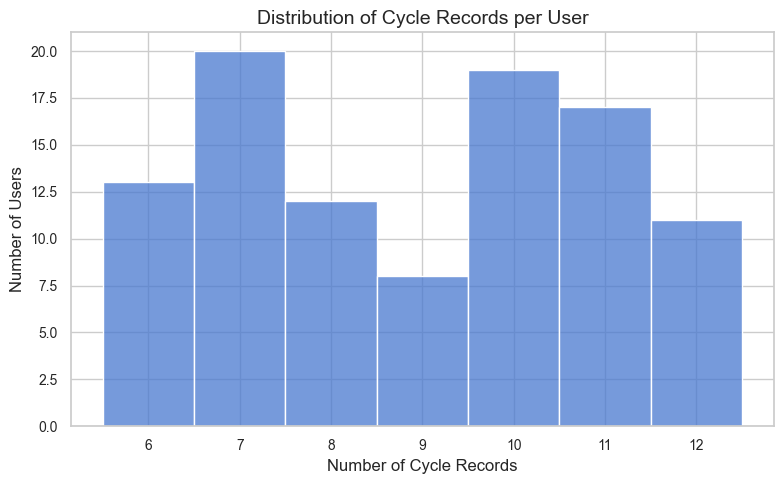

In [41]:
# Distribution of cycle records per user

records_per_user = df.groupby("User ID").size().rename("cycle_count")

plt.figure(figsize=(8, 5))

sns.histplot(
    records_per_user,
    bins=range(records_per_user.min(), records_per_user.max() + 2),
    discrete=True
)

plt.title("Distribution of Cycle Records per User")
plt.xlabel("Number of Cycle Records")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()

In [42]:
# ── Identify users with very few cycle records ─────────────────────────────

LOW_RECORD_THRESHOLD = 3  # Minimum number of cycle records for user-level pattern analysis

low_record_users = records_per_user[records_per_user <= LOW_RECORD_THRESHOLD]

if len(low_record_users) > 0:
    print(f"Users with <= {LOW_RECORD_THRESHOLD} cycle records:")
    print(low_record_users.to_string())
else:
    print(
        f"No users found with <= {LOW_RECORD_THRESHOLD} cycle records. "
        "All users have enough repeated cycle records for user-level analysis."
    )

No users found with <= 3 cycle records. All users have enough repeated cycle records for user-level analysis.


> **Why user-level splitting is essential:**  
> This dataset contains longitudinal repeated-measures data: each user contributes multiple cycle records over time. If the dataset is split randomly at the row level, cycle records from the same user may appear in both training and validation/test sets. This would create data leakage because the model could indirectly learn user-specific baseline patterns during training and then be evaluated on the same users.
>
> **Correct approach for this case:**  
> Users should be assigned entirely to one split, such as train, validation, or test. This evaluates whether the model can generalize to unseen users rather than memorizing user-specific patterns. A typical split could be 70% of users for training, 15% for validation, and 15% for testing. If possible, the split can be checked against age, cycle length, or other summary statistics to ensure that the splits remain reasonably balanced.
>
> **Additional note:**  
> In a deployed menstrual tracking product, another valid evaluation setup could be a temporal split within each user, where earlier cycles are used for training and later cycles are used for testing. However, because this assignment explicitly asks for user-level splitting, the primary evaluation should keep users separated across splits.

## 5. Numerical Feature Distributions

In [15]:
# ── Descriptive statistics ─────────────────────────────────────────────────
numerical_cols = ['Age', 'BMI', 'Stress Level', 'Sleep Hours',
                  'Cycle Length', 'Period Length']

df[numerical_cols].describe().round(2)

,Age,BMI,Stress Level,Sleep Hours,Cycle Length,Period Length
count,895.00,895.00,895.00,895.00,895.00,895.00
mean,31.02,24.48,3.08,6.99,37.37,5.02
std,8.28,3.18,1.44,1.22,7.47,1.39
min,18.00,18.55,1.00,5.10,25.00,3.00
25%,25.00,21.78,2.00,5.70,31.00,4.00
50%,31.00,24.38,3.00,7.10,37.00,5.00
75%,38.00,26.97,4.00,8.00,43.00,6.00
max,45.00,29.57,5.00,9.00,50.00,7.00


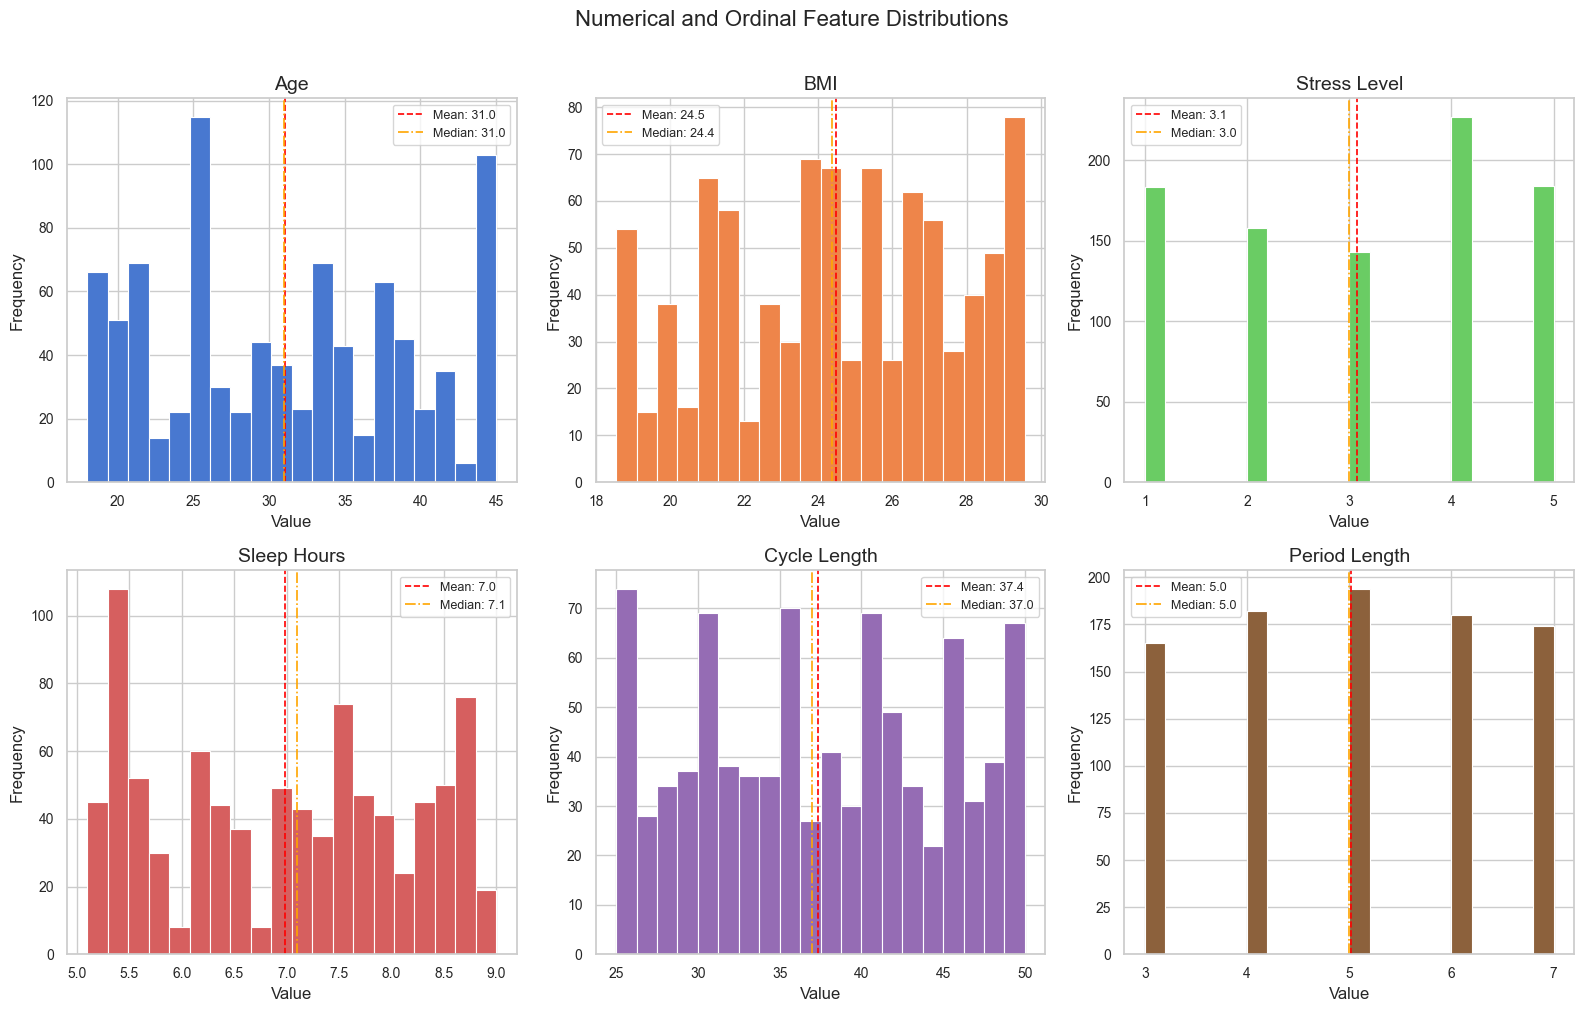

In [46]:
# ── Histograms ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

colors = sns.color_palette('muted', len(numerical_cols))

for i, col in enumerate(numerical_cols):
    axes[i].hist(
        df[col].dropna(),
        bins=20,
        color=colors[i],
        edgecolor='white',
        linewidth=0.8
    )
    axes[i].axvline(
        df[col].mean(),
        color='red',
        linestyle='--',
        linewidth=1.2,
        label=f'Mean: {df[col].mean():.1f}'
    )
    axes[i].axvline(
        df[col].median(),
        color='orange',
        linestyle='-.',
        linewidth=1.2,
        label=f'Median: {df[col].median():.1f}'
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    
    # Show only valid integer values for discrete/ordinal variables
    if col in ["Stress Level", "Period Length"]:
        axes[i].set_xticks(sorted(df[col].dropna().unique()))
    
    axes[i].legend(fontsize=9)

plt.suptitle('Numerical and Ordinal Feature Distributions', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

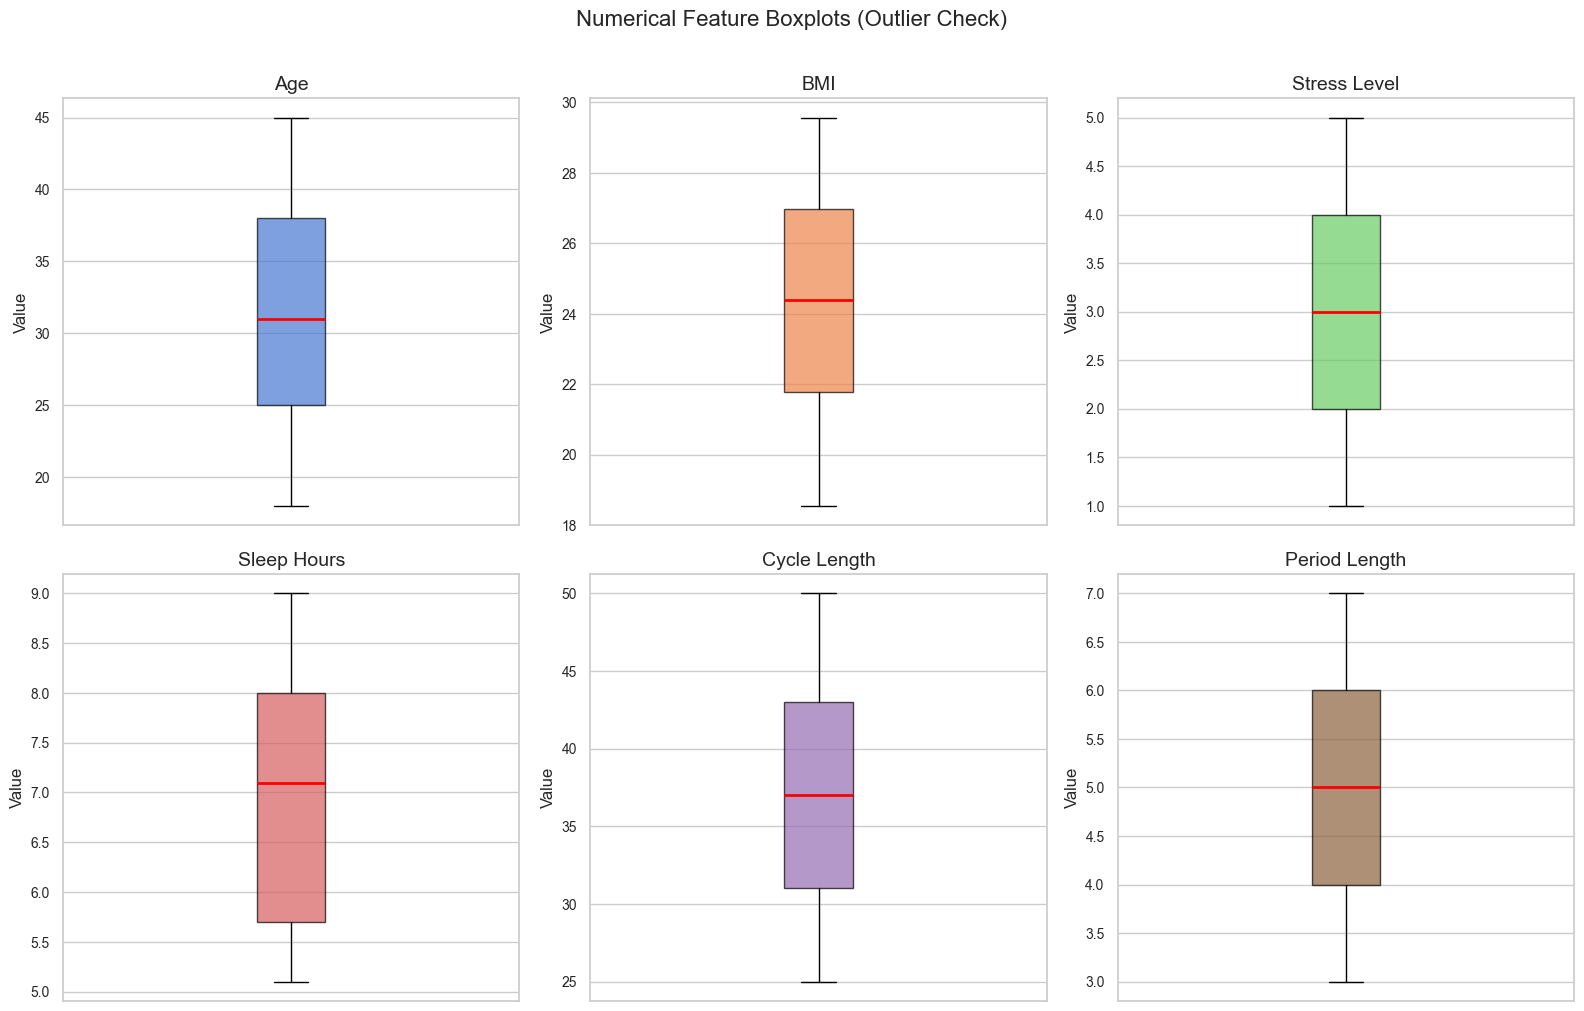

In [47]:
# ── Boxplots ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor=colors[i], alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')
    axes[i].set_xticks([])

plt.suptitle('Numerical Feature Boxplots (Outlier Check)', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

> **Interpretation notes:**
> - **Age:** The dataset covers a broad adult age range. Age is a static user-level feature, so it will later be repeated across timesteps or represented as a user-level input inside the sequence.
> - **BMI:** BMI values fall within a moderate synthetic range and do not show extreme outliers. Since BMI is also static, it may help the model learn user-level baseline differences.
> - **Stress Level:** Stress Level is a bounded ordinal feature. Although it is represented numerically, it should be interpreted as ordered categories rather than a fully continuous measurement.
> - **Sleep Hours:** Sleep Hours varies across records and may provide useful lifestyle context. In the later daily-expanded sequence, this feature will be repeated across generated days because the available dataset is cycle-level rather than truly daily.
> - **Cycle Length:** Cycle Length shows noticeable variability across records. This supports the need for personalized sequence modeling instead of relying on a single global average cycle length.
> - **Period Length:** Period Length is a bounded discrete variable. It is useful for deriving the menstruation phase duration and should be treated as cycle-specific information.
>
> Overall, the numerical features do not show extreme outliers requiring removal. Continuous numerical features will be scaled before being passed into the LSTM. Bounded ordinal/discrete variables such as `Stress Level` and `Period Length` will be handled carefully so that their ordering is preserved without over-interpreting them as fully continuous clinical measurements.

## 6. Categorical Feature Distributions

In [18]:
# ── Unique values ──────────────────────────────────────────────────────────
categorical_cols = ['Exercise Frequency', 'Diet', 'Symptoms']

for col in categorical_cols:
    print(f'{col}: {sorted(df[col].unique())}')

Exercise Frequency: ['High', 'Low', 'Moderate']
Diet: ['Balanced', 'High Sugar', 'Low Carb', 'Vegetarian']
Symptoms: ['Bloating', 'Cramps', 'Fatigue', 'Headache', 'Mood Swings']


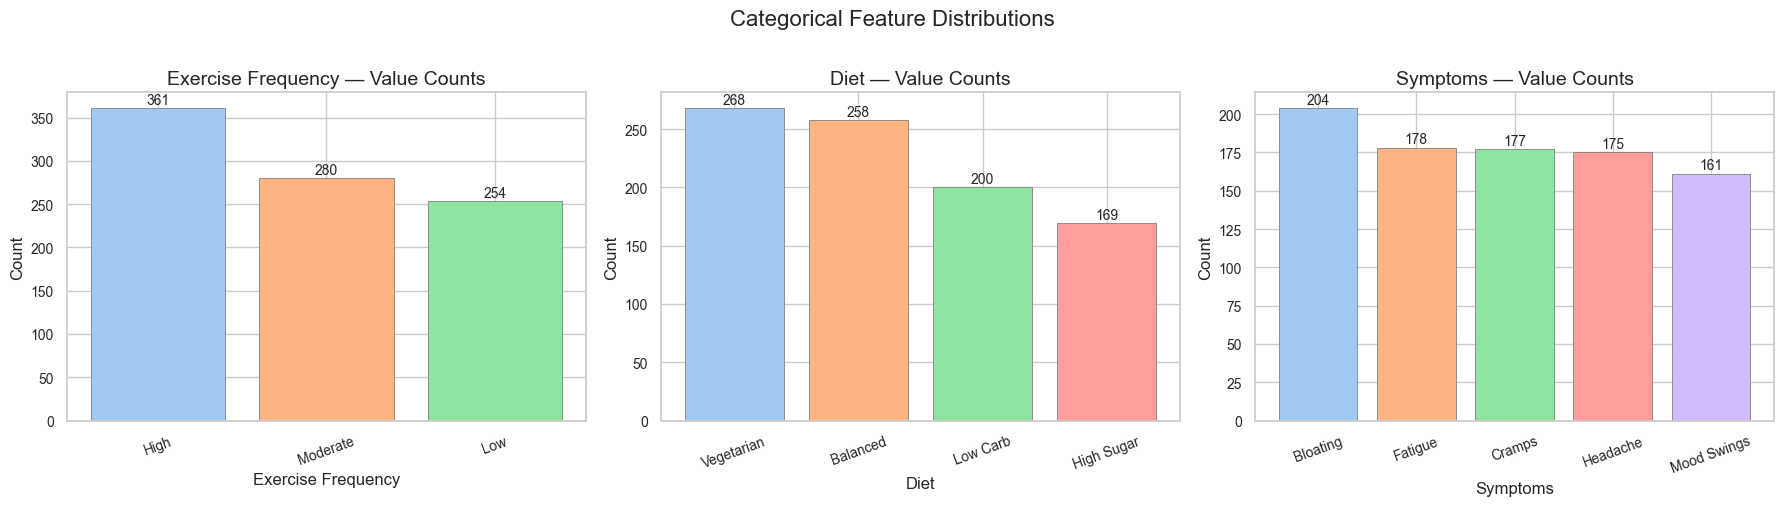

In [19]:
# ── Countplots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(categorical_cols):
    value_counts = df[col].value_counts()
    palette = sns.color_palette('pastel', len(value_counts))
    axes[i].bar(value_counts.index, value_counts.values,
                color=palette, edgecolor='grey', linewidth=0.6)
    axes[i].set_title(f'{col} — Value Counts')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=20)

    # Annotate bar heights
    for bar, val in zip(axes[i].patches, value_counts.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 1,
                     str(val), ha='center', va='bottom', fontsize=10)

plt.suptitle('Categorical Feature Distributions', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [20]:
# ── Check whether Symptoms is single-label or multi-label ─────────────────

# A multi-label symptom column would contain comma-separated values like
# 'Cramps, Bloating'. Check if any rows contain common separators.
has_multiple = df['Symptoms'].str.contains(',|;|/', na=False).any()

print(f'Symptoms column contains multi-label entries: {has_multiple}')
print('\nAll unique symptom values and counts:')
print(df['Symptoms'].value_counts().to_string())

Symptoms column contains multi-label entries: False

All unique symptom values and counts:
Symptoms
Bloating       204
Fatigue        178
Cramps         177
Headache       175
Mood Swings    161


> **Encoding choices for the model:**
>
> | Feature | Type | Candidate Encoding |
> |---|---|---|
> | **Exercise Frequency** | Ordinal categorical (Low / Moderate / High) | Ordinal integer encoding (`Low=0`, `Moderate=1`, `High=2`) or one-hot encoding |
> | **Diet** | Nominal categorical | One-hot encoding (4 categories → 4 binary columns) |
> | **Symptoms** | Single-label categorical, based on the check above | One-hot encoding (one column per symptom category) |
>
> `Exercise Frequency` has a natural order, so ordinal encoding is a reasonable first choice. This preserves the progression from low to moderate to high activity. However, ordinal encoding also assumes that the distance between adjacent levels is approximately equal, which may not fully reflect real behavior. Therefore, I will treat ordinal encoding as the default candidate and compare it with one-hot encoding during preprocessing/model experiments if needed.
>
> `Diet` and `Symptoms` do not have a natural ordering, so one-hot encoding is more appropriate for them.
>
> If `Symptoms` were multi-label, such as `"Cramps, Bloating"`, the correct approach would be multi-hot encoding: a binary vector with one position per symptom type, where multiple positions can be active at the same time. In this dataset, no multi-label symptom entries were found, so `Symptoms` is treated as a single-label categorical feature.
>
> These encoded features will be included in the per-cycle feature vector. Because the provided dataset is cycle-level rather than truly daily, these values will later be broadcast across the generated daily timesteps within each sequence window.

## 7. Relationship Analysis

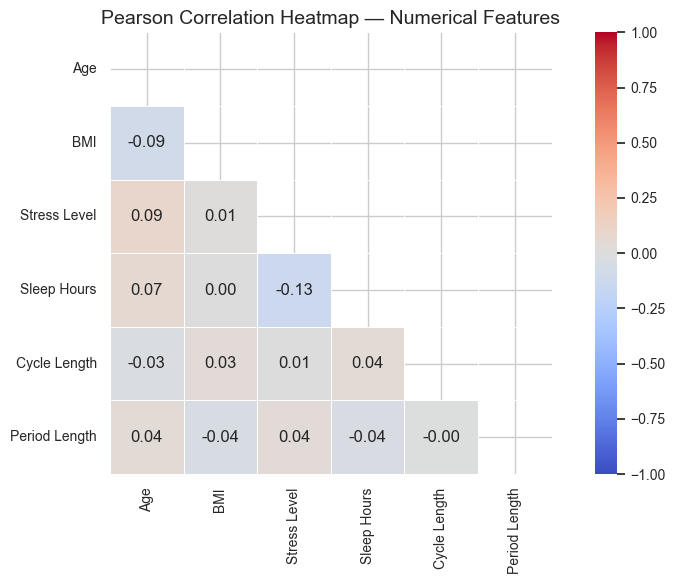

In [48]:
# ── Correlation heatmap — numeric features only ────────────────────────────

corr_cols = [
    "Age",
    "BMI",
    "Stress Level",
    "Sleep Hours",
    "Cycle Length",
    "Period Length"
]

corr_matrix = df[corr_cols].corr(method="pearson")

plt.figure(figsize=(9, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True
)

plt.title("Pearson Correlation Heatmap — Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()

> **Interpretation notes:**
>
> - The correlation heatmap shows pairwise linear relationships between numerical features.
> - Most correlations are weak, suggesting that no single numerical feature has a strong global linear association with another in this synthetic dataset.
> - This does not mean the features are uninformative for the model. Menstrual cycle behavior is user-specific and temporal, so useful signals may appear through sequence patterns, feature interactions, or user-level variability rather than simple pairwise correlations.
> - Correlation should not be interpreted causally. For example, even if stress and cycle length were correlated, this would not prove that stress directly causes cycle length changes.
> - `computed_cycle_length` was excluded from this heatmap because it was created only as a data validation helper and duplicates the information in `Cycle Length`.

## 8. Cycle Pattern and Variability Analysis

In [23]:
# ── User-level aggregated statistics ──────────────────────────────────────
user_stats = df.groupby('User ID').agg(
    mean_cycle_length=('Cycle Length', 'mean'),
    std_cycle_length=('Cycle Length', 'std'),
    mean_period_length=('Period Length', 'mean'),
    mean_stress=('Stress Level', 'mean'),
    mean_sleep=('Sleep Hours', 'mean'),
    n_cycles=('Cycle Length', 'count')
).reset_index()

# Fill NaN std (users with only 1 record have undefined std)
user_stats['std_cycle_length'] = user_stats['std_cycle_length'].fillna(0)

print('User-level statistics (first 5 users):')
user_stats.head()

User-level statistics (first 5 users):


,User ID,mean_cycle_length,std_cycle_length,mean_period_length,mean_stress,mean_sleep,n_cycles
0,1,36.909091,8.055489,4.909091,2.0,5.4,11
1,2,34.444444,6.023104,5.444444,4.0,5.4,9
2,3,40.200000,8.689713,4.000000,1.0,8.6,10
3,4,40.200000,7.130529,4.800000,2.0,8.3,10
4,5,38.333333,6.227992,5.333333,1.0,6.3,12


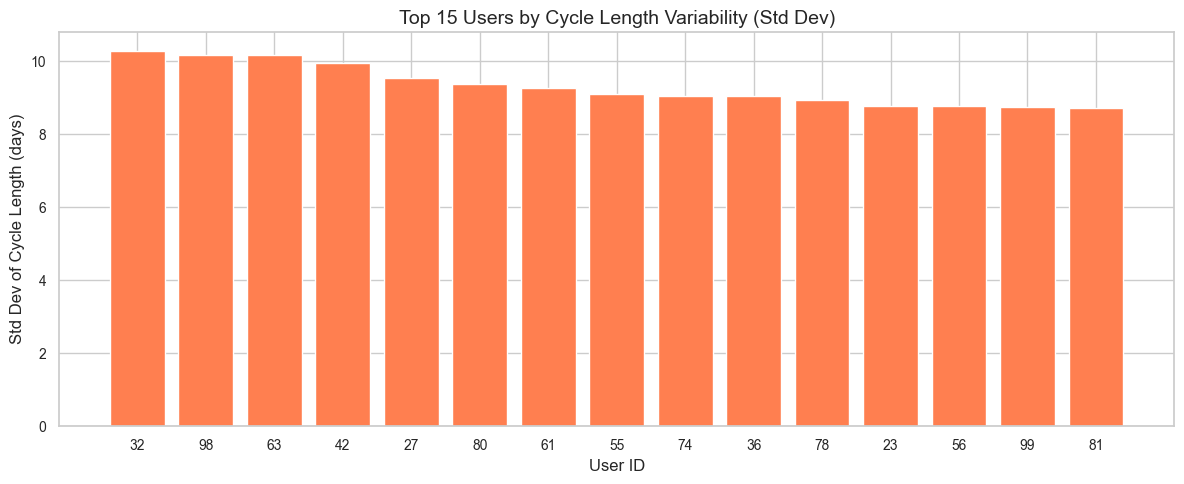

In [24]:
# ── Top users by cycle length variability ─────────────────────────────────
top_variable = user_stats.nlargest(15, 'std_cycle_length')

plt.figure(figsize=(12, 5))
plt.bar(top_variable['User ID'].astype(str), top_variable['std_cycle_length'],
        color='coral', edgecolor='white')
plt.title('Top 15 Users by Cycle Length Variability (Std Dev)', fontsize=14)
plt.xlabel('User ID')
plt.ylabel('Std Dev of Cycle Length (days)')
plt.tight_layout()
plt.show()

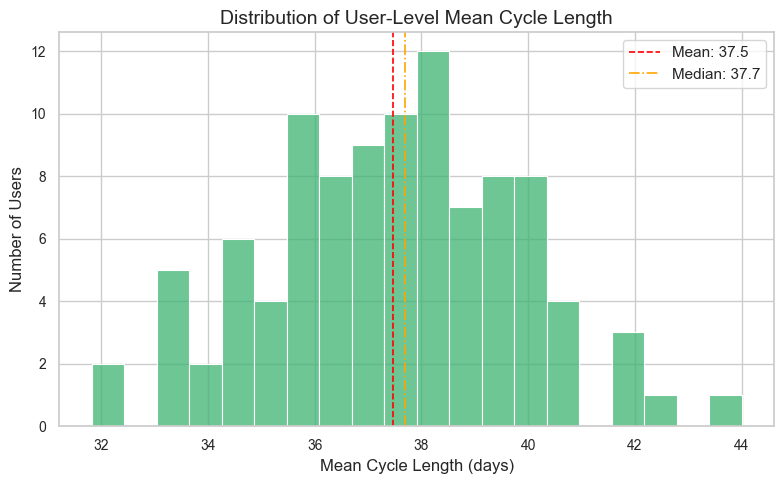

In [53]:
# ── Distribution of user-level mean cycle length ───────────────────────────

plt.figure(figsize=(8, 5))

sns.histplot(
    user_stats["mean_cycle_length"],
    bins=20,
    color="mediumseagreen",
    edgecolor="white",
    linewidth=0.8
)
plt.axvline(
    user_stats["mean_cycle_length"].mean(),
    color="red",
    linestyle="--",
    linewidth=1.2,
    label=f"Mean: {user_stats['mean_cycle_length'].mean():.1f}"
)
plt.axvline(
    user_stats["mean_cycle_length"].median(),
    color="orange",
    linestyle="-.",
    linewidth=1.2,
    label=f"Median: {user_stats['mean_cycle_length'].median():.1f}"
)

plt.title("Distribution of User-Level Mean Cycle Length")
plt.xlabel("Mean Cycle Length (days)")
plt.ylabel("Number of Users")
plt.legend()
plt.tight_layout()
plt.show()

> **Why personal variability matters for sequential modeling:**
>
> User-level aggregation shows that users differ in both their average cycle length and the variability of cycle length across records. This makes a fixed global estimate insufficient for next-cycle prediction.
>
> The distribution of user-level mean cycle length captures baseline differences between users, while the top variability plot highlights users whose cycle timing is less stable across cycles. These patterns motivate a sequence-based approach: instead of predicting from a single row independently, the model can use recent cycle context within a window.
>
> An LSTM is suitable here because it can learn temporal dependencies and short-term cycle history from the input sequence. This is especially relevant for the regression head, where predicting `days_until_next_cycle` requires understanding both the current position in the cycle and the user's recent rhythm.

## 9. Temporal Analysis

In [27]:
# ── Extract temporal features ──────────────────────────────────────────────
df['cycle_year']       = df['Cycle Start Date'].dt.year
df['cycle_month']      = df['Cycle Start Date'].dt.month
df['cycle_year_month'] = df['Cycle Start Date'].dt.to_period('M')

# Dataset time range
print(f"Earliest cycle start : {df['Cycle Start Date'].min().date()}")
print(f"Latest cycle start   : {df['Cycle Start Date'].max().date()}")
print(f"Time span            : {(df['Cycle Start Date'].max() - df['Cycle Start Date'].min()).days} days")

Earliest cycle start : 2023-03-20
Latest cycle start   : 2026-05-21
Time span            : 1158 days


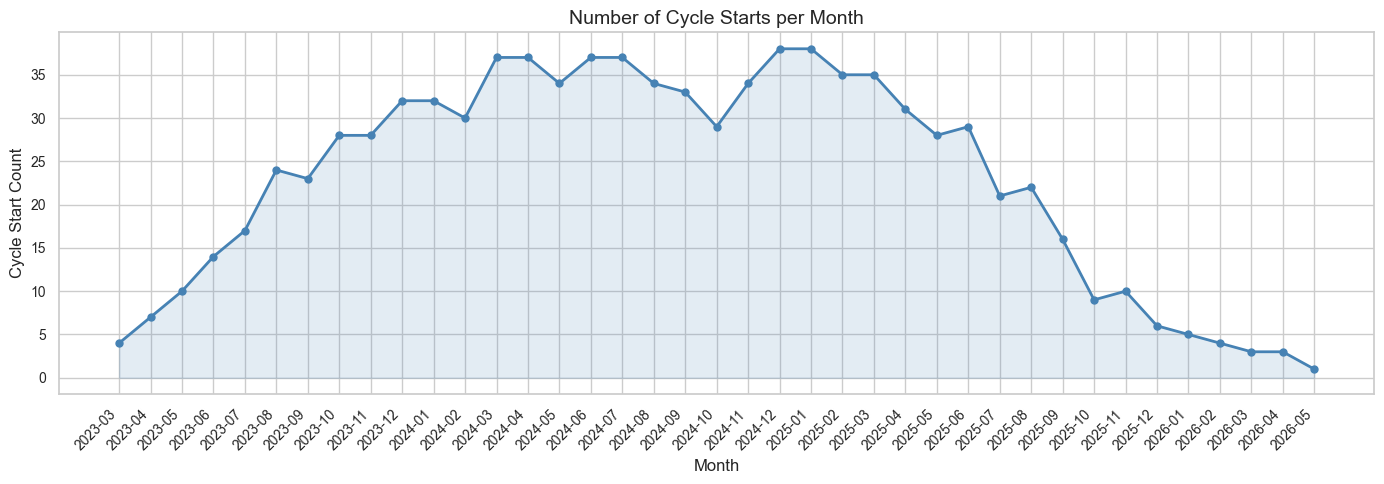

In [28]:
# ── Cycle starts over time (monthly aggregation) ───────────────────────────
monthly_counts = (
    df.groupby('cycle_year_month').size()
    .rename('cycle_starts')
    .reset_index()
)
monthly_counts['period_str'] = monthly_counts['cycle_year_month'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly_counts['period_str'], monthly_counts['cycle_starts'],
         marker='o', linewidth=2, color='steelblue', markersize=5)
plt.fill_between(monthly_counts['period_str'], monthly_counts['cycle_starts'],
                 alpha=0.15, color='steelblue')
plt.title('Number of Cycle Starts per Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Cycle Start Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

> **Date handling interpretation:**
>
> The dataset covers cycle start dates from 2023-03-20 to 2026-05-21, spanning approximately 1158 days. The monthly cycle-start count shows that the dataset has a defined observation window, with lower counts near the beginning and end of the range. This likely reflects dataset boundary effects rather than a biological pattern.
>
> Raw datetime values will not be used directly as model inputs. Instead, dates will be transformed into relative temporal features during daily sequence construction. The most important derived feature is `day_index_in_cycle`, which tells the model where the current day is within the ongoing cycle. The regression target, `days_until_next_cycle`, will also be derived from `Next Cycle Start Date`.
>
> Although calendar month could theoretically be encoded using sine and cosine transformations, I do not treat it as a central feature in this version. The more biologically meaningful temporal signal is the relative position within the cycle, not the absolute month of the year. Therefore, date handling will focus on derived cycle-relative features such as `day_index_in_cycle`, `phase_label`, and `days_until_next_cycle`.

| Derived Feature | Description | Role |
|---|---|---|
| `day_index_in_cycle` | Day number within the current cycle | Main temporal input |
| `days_until_next_cycle` | Days remaining until next cycle start | Regression target |
| `phase_label` | Menstruation / Follicular / Ovulation / Luteal derived from cycle day | Classification target |
| `month_sin`, `month_cos` | Cyclical calendar-month encoding |  Optional candidate, not central in this version |

## 10. Initial Target Engineering Preview

In [30]:
# ── Preview: days_until_next_cycle at cycle start ─────────────────────────
# This is the regression target value at day 0 of each cycle.
# In the expanded daily dataset, this value will count DOWN each day:
#   Day 0 -> full cycle length, Day 1 -> cycle length - 1, ..., Day N -> 0

df['days_until_next_cycle_at_cycle_start'] = (
    df['Next Cycle Start Date'] - df['Cycle Start Date']
).dt.days

print('Preview -- days_until_next_cycle at cycle start (first 8 rows):')
df[['User ID', 'Cycle Start Date', 'Next Cycle Start Date',
    'days_until_next_cycle_at_cycle_start']].head(8)

Preview -- days_until_next_cycle at cycle start (first 8 rows):


,User ID,Cycle Start Date,Next Cycle Start Date,days_until_next_cycle_at_cycle_start
0,1,2024-11-13 20:52:34.915012,2024-12-09 20:52:34.915012,26
1,1,2024-12-09 20:52:34.915012,2025-01-10 20:52:34.915012,32
2,1,2025-01-10 20:52:34.915012,2025-02-20 20:52:34.915012,41
3,1,2025-02-20 20:52:34.915012,2025-03-19 20:52:34.915012,27
4,1,2025-03-19 20:52:34.915012,2025-04-30 20:52:34.915012,42
5,1,2025-04-30 20:52:34.915012,2025-06-10 20:52:34.915012,41
6,1,2025-06-10 20:52:34.915012,2025-07-11 20:52:34.915012,31
7,1,2025-07-11 20:52:34.915012,2025-08-28 20:52:34.915012,48


> **Important note for the modeling stage:**
>
> `days_until_next_cycle_at_cycle_start` is a preview of the regression target at day 0 of each cycle. It is calculated as the difference between `Next Cycle Start Date` and `Cycle Start Date`.
>
> This value is equal to the full cycle length at the start of the cycle. In the later daily-expanded dataset, this target will become dynamic: it will decrease by 1 at each generated day until the next cycle starts.
>
> For example, if a cycle length is 28 days:
>
> ```
> Day 0  -> days_until_next_cycle = 28
> Day 1  -> days_until_next_cycle = 27
> Day 2  -> days_until_next_cycle = 26
> ...
> Day 27 -> days_until_next_cycle = 1
> Day 28 -> new cycle starts
> ```
>
> This notebook only previews the target engineering logic. The full daily expansion and sequence-window construction will be performed in the feature engineering / sequence preparation stage.

## 11. Static vs. Cycle-Level Consistency Check

Before finalizing the EDA summary, I checked whether selected features are constant within each user or vary across that user's cycle records. This helps decide whether a feature should be treated as static/user-level or cycle-level during sequence construction.

In [54]:
# Check whether selected features are constant per user

candidate_static_cols = [
    "Age",
    "BMI",
    "Exercise Frequency",
    "Diet",
    "Stress Level",
    "Sleep Hours",
    "Symptoms"
]

per_user_unique_counts = pd.DataFrame({
    col: df.groupby("User ID")[col].nunique()
    for col in candidate_static_cols
})

max_unique_per_user = per_user_unique_counts.max().rename("max_unique_values_per_user")

max_unique_per_user

Age                   1
BMI                   1
Exercise Frequency    1
Diet                  1
Stress Level          1
Sleep Hours           1
Symptoms              5
Name: max_unique_values_per_user, dtype: int64

> **Interpretation:**  
> `Age`, `BMI`, `Exercise Frequency`, `Diet`, `Stress Level`, and `Sleep Hours` each have only one unique value per user in this synthetic dataset. Therefore, they behave as static user-level features here and will be repeated across generated daily timesteps during sequence construction.
>
> `Symptoms` has up to 5 unique values per user, meaning that symptom labels vary across a user's cycle records. Therefore, `Symptoms` should be treated as a cycle-level categorical feature.
>
> In a real tracking system, stress and sleep would ideally be recorded daily or at least cycle-by-cycle. The static behavior observed here is a limitation of the synthetic dataset and should be noted in the report.

## 12. EDA Summary for Report

---

### What the dataset contains

The dataset contains **895 menstrual cycle records** from **100 unique users**, with **6 to 12 cycle records per user** and an average of approximately **9 records per user**. Each row represents one complete menstrual cycle annotated with user-level, lifestyle, symptom, and temporal information.

The dataset is fully populated, with no missing values across the 12 original columns. The temporal fields are also internally consistent: the provided `Cycle Length` values match the difference between `Cycle Start Date` and `Next Cycle Start Date`.

---

### Static vs. Cycle-Level Features

| Feature | Type in this dataset | Notes |
|---|---|---|
| `User ID` | Identifier | Used for grouping and user-level splitting, not as a predictive feature |
| `Age` | Static user-level feature | Constant for each user |
| `BMI` | Static user-level feature | Constant for each user |
| `Exercise Frequency` | Static lifestyle feature | Constant for each user |
| `Diet` | Static lifestyle feature | Constant for each user |
| `Stress Level` | Static user-level feature in this dataset | Conceptually could vary over time, but is constant per user here |
| `Sleep Hours` | Static user-level feature in this dataset | Conceptually could vary daily, but is constant per user here |
| `Cycle Start Date` | Temporal field | Used to derive cycle-relative time features |
| `Next Cycle Start Date` | Temporal / target source | Used only to derive the regression target |
| `Cycle Length` | Cycle-level summary | Required by the assignment; potential leakage risk in real-time forecasting |
| `Period Length` | Cycle-level summary | Used for phase-label derivation, especially menstruation duration |
| `Symptoms` | Cycle-level categorical feature | Single-label symptom category; varies across cycles |

Because the dataset is cycle-level rather than truly daily, static and cycle-level values will be broadcast across the generated daily timesteps during sequence construction. In a real tracking system, variables such as symptoms, stress, and sleep would ideally vary day by day.

---

### Features that need encoding

| Feature | Strategy |
|---|---|
| `Exercise Frequency` | Ordinal integer encoding (`Low=0`, `Moderate=1`, `High=2`) as a reasonable first choice; one-hot encoding can be tested as an alternative |
| `Diet` | One-hot encoding because it is nominal |
| `Symptoms` | One-hot encoding because the column is single-label in this dataset |

If `Symptoms` were multi-label, such as `"Cramps, Bloating"`, the correct strategy would be multi-hot encoding. However, the EDA confirmed that each row contains only one symptom category.

---

### Features that need scaling

Continuous numerical features should be scaled before modeling so that the LSTM receives inputs on comparable numeric ranges.

| Feature | Suggested Treatment |
|---|---|
| `Age`, `BMI`, `Sleep Hours` | StandardScaler or MinMaxScaler |
| `Stress Level` | Bounded ordinal feature; can be min-max scaled if treated numerically |
| `Cycle Length`, `Period Length` | StandardScaler or MinMaxScaler |
| `day_index_in_cycle` | Normalize by maximum cycle length or selected sequence length |
| `days_until_next_cycle` | Regression target; can be kept in days for interpretability or scaled during training with inverse transform for evaluation |

> **Important:** Any scalers must be fit on training users only, then applied to validation and test users to prevent data leakage.

---

### Why dates require transformation

Raw datetime values are not directly suitable as model inputs. They will be converted into cycle-relative temporal features:

- **`day_index_in_cycle`**: positional context within the current cycle
- **`days_until_next_cycle`**: regression target, decreasing daily
- **`phase_label`**: classification target derived from cycle day, period length, and cycle structure
- **`month_sin` / `month_cos`**: optional calendar-month encoding, not central in this version

The main temporal signal is the user's relative position within the menstrual cycle rather than the absolute calendar date.

---

### Why user-level splitting is required

The dataset contains repeated records from the same users. If rows were split randomly, cycles from the same user could appear in both training and evaluation sets. This would create data leakage because the model could indirectly learn user-specific baseline patterns during training and then be evaluated on the same users.

The correct approach for this assignment is to assign each user entirely to one partition: train, validation, or test. This gives a more realistic estimate of how well the model generalizes to unseen users.

---

### How EDA informs later sequence design

1. **Sequence construction:** The original dataset is cycle-level, so each cycle record must be expanded into daily rows before creating fixed-length sequence windows.

2. **Window length:** Cycle lengths range from **25 to 50 days** in this dataset. Sequence lengths such as 14 and 21 days can be tested as required optimization experiments, while longer cycle context may require padding or masking.

3. **User variability:** Users differ in both average cycle length and cycle length variability. This supports using sequence-based modeling rather than relying on a single global cycle estimate.

4. **Regression target:** `days_until_next_cycle` is meaningful because it captures the countdown to the next cycle start and changes each day in the expanded dataset.

5. **Cycle phase classification:** The phase label can be derived during preprocessing using `day_index_in_cycle`, `Period Length`, and cycle structure assumptions.

6. **Multi-task learning rationale:** A shared LSTM encoder can learn a representation of cycle state that supports both outputs: phase classification and next-cycle countdown regression.

7. **Leakage awareness:** `Next Cycle Start Date` should not be used as a direct input feature. It is used only to derive the regression target. Similarly, `Cycle Length` is required by the assignment, but in a real-time forecasting system the current cycle's final length may not be known in advance, so this limitation should be discussed.